# Decay curve debug
Investigating the systematic offset between IK-estimated ρ and spectral ρ for nuc models.

**Part 1**: Raw decay curve for ParD3, nuc_uniform — overlay actual data, IK fit, and spectral prediction  
**Part 2**: Manual JAX/vmap neutral-mutation decay curves for TEV, nuc_uniform (no simulation framework)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from direvo_functions import get_single_decay_rate_IK_v2, model_function_IK_v2

SLIDE_DATA = 'SLIDE_data'
PLOT_DATA  = 'plot_data'
LANDSCAPE_DIR = 'landscape_arrays'

# Spectral rho reference
with open(f'{PLOT_DATA}/spectral_rho_comparison.pkl', 'rb') as f:
    spectral = pickle.load(f)

print('Spectral rho (nuc_uniform):')
for ld in ['GB1','TrpB','TEV','ParD3']:
    print(f'  {ld}: {spectral[ld]["nuc_uniform"]:.4f}')

Spectral rho (nuc_uniform):
  GB1: 0.4157
  TrpB: 0.3040
  TEV: 0.2488
  ParD3: 0.3380


## Part 1: ParD3 — raw decay curve vs IK fit vs spectral

In [2]:
# Load raw decay data: shape (80, 100, 10, 25) → mean over seeds → (8000, 25)
with open(f'{SLIDE_DATA}/decay_curves_pard3_nuc_uniform_m0.1_all_starts_v2.pkl', 'rb') as f:
    raw = pickle.load(f)

# h[i, t] = mean fitness at time t, averaged over 10 random seeds, for starting point i
h = raw.mean(axis=2).reshape(-1, 25)   # (8000, 25)
print(f'h shape: {h.shape}')

# The IK estimator uses E[h²](t) — squaring first, then averaging over starting points
curve = (h**2).mean(axis=0)            # (25,)
steps = np.arange(25)

print(f'curve[0]  = {curve[0]:.5f}  (= E[f(x)²] at t=0)')
print(f'curve[-1] = {curve[-1]:.5f}  (approaches μ² as t→∞)')
print(f'sqrt(curve[0])  = {np.sqrt(curve[0]):.5f}  (≈ rms fitness)')
print(f'sqrt(curve[-1]) = {np.sqrt(curve[-1]):.5f}  (≈ mean fitness)')

h shape: (8000, 25)
curve[0]  = 0.14528  (= E[f(x)²] at t=0)
curve[-1] = 0.07761  (approaches μ² as t→∞)
sqrt(curve[0])  = 0.38116  (≈ rms fitness)
sqrt(curve[-1]) = 0.27859  (≈ mean fitness)


In [3]:
# Run the IK fit (same as compute_trajectory_subsampling.py)
rho_ik_raw, C, c = get_single_decay_rate_IK_v2(curve, mut=0.1)
rho_ik = rho_ik_raw / 2   # divide by 2 (squaring doubles the rate)

rho_spec = spectral['ParD3']['nuc_uniform']

print(f'IK fitted rho (÷2): {rho_ik:.4f}')
print(f'Spectral rho:       {rho_spec:.4f}')
print(f'Difference:         {rho_ik - rho_spec:.4f}  ({100*(rho_ik-rho_spec)/rho_spec:.1f}%)')

IK fitted rho (÷2): 0.3528
Spectral rho:       0.3380
Difference:         0.0148  (4.4%)


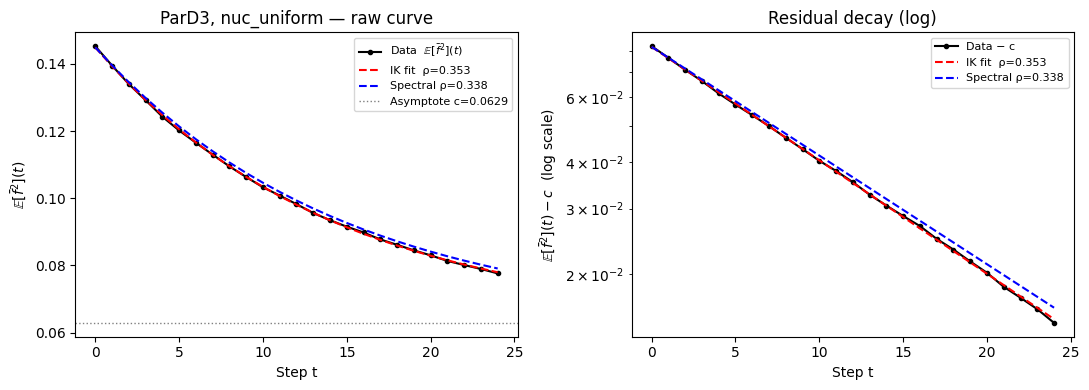

In [4]:
# Build the two model curves (IK fit uses rho*2 because of squaring)
fit_ik   = model_function_IK_v2(steps, rho_ik_raw,  C, c, mut=0.1)
fit_spec = model_function_IK_v2(steps, rho_spec * 2, C, c, mut=0.1)  # same C,c; only rate differs

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Left: raw E[h²](t) ---
ax = axes[0]
ax.plot(steps, curve,    'k.-',  lw=1.5, label='Data  $\\mathbb{E}[\\bar{f}^2](t)$')
ax.plot(steps, fit_ik,   'r--',  lw=1.5, label=f'IK fit  ρ={rho_ik:.3f}')
ax.plot(steps, fit_spec, 'b--',  lw=1.5, label=f'Spectral ρ={rho_spec:.3f}')
ax.axhline(c, color='grey', ls=':', lw=1, label=f'Asymptote c={c:.4f}')
ax.set_xlabel('Step t')
ax.set_ylabel('$\\mathbb{E}[\\bar{f}^2](t)$')
ax.set_title('ParD3, nuc_uniform — raw curve')
ax.legend(fontsize=8)

# --- Right: subtract asymptote, log scale ---
ax = axes[1]
eps = 1e-10
ax.semilogy(steps, curve - c + eps,    'k.-',  lw=1.5, label='Data − c')
ax.semilogy(steps, fit_ik - c + eps,   'r--',  lw=1.5, label=f'IK fit  ρ={rho_ik:.3f}')
ax.semilogy(steps, fit_spec - c + eps, 'b--',  lw=1.5, label=f'Spectral ρ={rho_spec:.3f}')
ax.set_xlabel('Step t')
ax.set_ylabel('$\\mathbb{E}[\\bar{f}^2](t) - c$  (log scale)')
ax.set_title('Residual decay (log)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/debug_pard3_nuc_uniform_decay_curve.pdf', bbox_inches='tight')
plt.show()

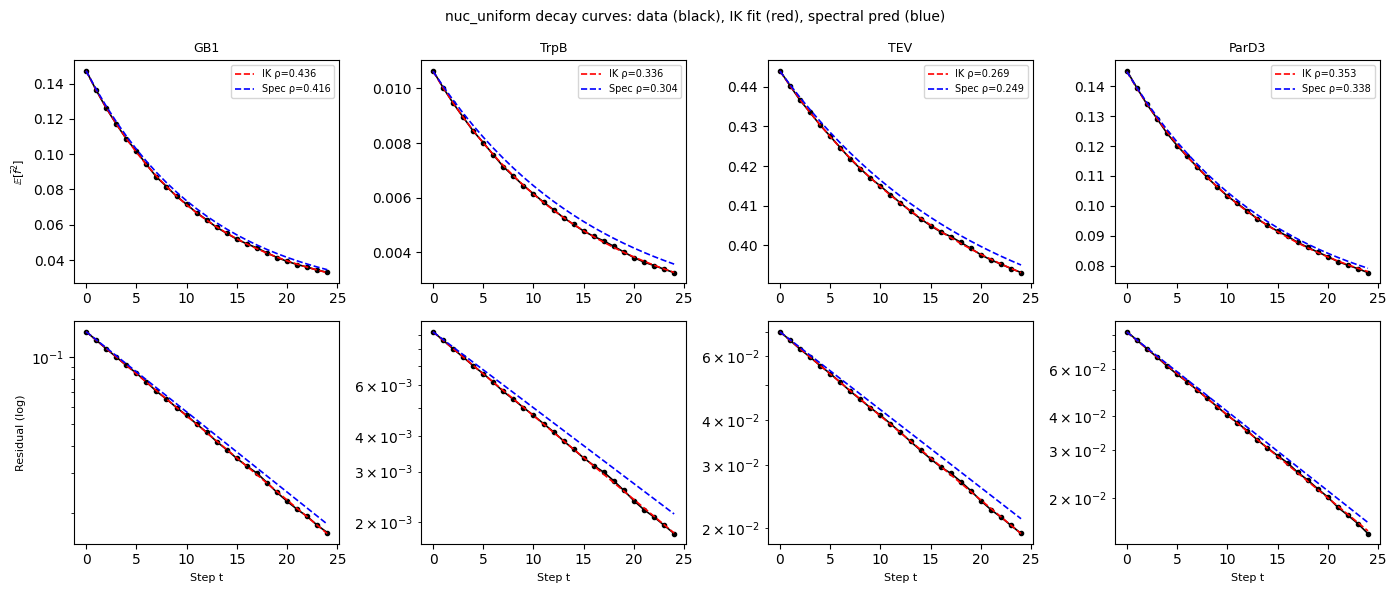

In [5]:
# Also show all 4 landscapes side by side
LANDSCAPES = {
    'gb1':   'GB1',
    'trpb':  'TrpB',
    'tev':   'TEV',
    'pard3': 'ParD3',
}

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for col, (ld_key, ld_name) in enumerate(LANDSCAPES.items()):
    fpath = f'{SLIDE_DATA}/decay_curves_{ld_key}_nuc_uniform_m0.1_all_starts_v2.pkl'
    with open(fpath, 'rb') as f:
        raw_ld = pickle.load(f)
    h_ld    = raw_ld.mean(axis=2).reshape(-1, 25)
    curve_ld = (h_ld**2).mean(axis=0)

    rho_raw, C_ld, c_ld = get_single_decay_rate_IK_v2(curve_ld, mut=0.1)
    rho_ik_ld   = rho_raw / 2
    rho_spec_ld = spectral[ld_name]['nuc_uniform']

    fit_ik_ld   = model_function_IK_v2(steps, rho_raw,         C_ld, c_ld, mut=0.1)
    fit_spec_ld = model_function_IK_v2(steps, rho_spec_ld * 2, C_ld, c_ld, mut=0.1)

    # Row 0: raw
    ax0 = axes[0, col]
    ax0.plot(steps, curve_ld,    'k.-', lw=1.2)
    ax0.plot(steps, fit_ik_ld,   'r--', lw=1.2, label=f'IK ρ={rho_ik_ld:.3f}')
    ax0.plot(steps, fit_spec_ld, 'b--', lw=1.2, label=f'Spec ρ={rho_spec_ld:.3f}')
    ax0.set_title(ld_name, fontsize=9)
    ax0.legend(fontsize=7)
    if col == 0: ax0.set_ylabel('$\\mathbb{E}[\\bar{f}^2]$', fontsize=8)

    # Row 1: log residual
    ax1 = axes[1, col]
    ax1.semilogy(steps, curve_ld - c_ld + eps,    'k.-', lw=1.2)
    ax1.semilogy(steps, fit_ik_ld - c_ld + eps,   'r--', lw=1.2)
    ax1.semilogy(steps, fit_spec_ld - c_ld + eps, 'b--', lw=1.2)
    ax1.set_xlabel('Step t', fontsize=8)
    if col == 0: ax1.set_ylabel('Residual (log)', fontsize=8)

plt.suptitle('nuc_uniform decay curves: data (black), IK fit (red), spectral pred (blue)', fontsize=10)
plt.tight_layout()
plt.savefig('figures/debug_all_landscapes_nuc_uniform_decay_curves.pdf', bbox_inches='tight')
plt.show()

## Part 2: Manual JAX decay curves for TEV, nuc_uniform

A minimal reimplementation — no population dynamics, no selection.  
Each individual evolves independently via pure neutral mutation.  
We directly compute $\mathbb{E}_{x_0}[f(x_t)^2]$ vs $t$ and compare to spectral.

In [6]:
import jax
import jax.numpy as jnp
import jax.random as jr

# Load TEV landscape
with open(f'{LANDSCAPE_DIR}/TEV_landscape_array.pkl', 'rb') as f:
    TEV = pickle.load(f)

n_aa  = TEV.ndim      # 4
n_nuc = n_aa * 3      # 12
MUT   = 0.1
site_rate = MUT / n_nuc
A = 4   # nucleotide alphabet

print(f'TEV: {n_aa} AA sites, {n_nuc} nuc sites')
print(f'Per-site mutation rate: {site_rate:.5f}')
print(f'Spectral rho (TEV, nuc_uniform): {spectral["TEV"]["nuc_uniform"]:.4f}')

TEV: 4 AA sites, 12 nuc sites
Per-site mutation rate: 0.00833
Spectral rho (TEV, nuc_uniform): 0.2488


In [7]:
from direvo_functions import get_pre_defined_landscape_function_with_codon

tev_jnp     = jnp.array(TEV)
fitness_fn_pop = get_pre_defined_landscape_function_with_codon(tev_jnp)  # expects (batch, n_nuc)
fitness_fn     = lambda seq: fitness_fn_pop(seq[None])[0]               # single-seq wrapper

test_seq = jnp.zeros((n_nuc,), dtype=jnp.int32)
print('Fitness of all-zero nuc seq:', fitness_fn(test_seq))


Fitness of all-zero nuc seq: 0.7289536


In [8]:
# --- Pure neutral mutation, no selection, no population ---
# One step: each site independently mutated with prob site_rate

@jax.jit
def mutate_step(key, seq):
    """Apply one step of uniform nuc mutation to a single sequence (n_nuc,)."""
    k1, k2 = jr.split(key)
    mask    = jr.bernoulli(k1, p=site_rate, shape=(n_nuc,))
    new_states = jr.randint(k2, shape=(n_nuc,), minval=0, maxval=A)
    return jnp.where(mask, new_states, seq)

def evolve_one(key, seq, T):
    """Evolve a single sequence for T steps; return fitness at each step (T,)."""
    keys = jr.split(key, T)
    def body(seq, k):
        seq = mutate_step(k, seq)
        return seq, fitness_fn(seq)
    _, fitnesses = jax.lax.scan(body, seq, keys)
    return fitnesses  # (T,)

# vmap over starting sequences
T = 50   # run longer than 25 to see the full curve
N_STARTS = 20**n_aa  # 160 000
N_REPS   = 5         # independent mutation realisations per starting point

print(f'Will run {N_STARTS} starts × {N_REPS} reps × {T} steps')

Will run 160000 starts × 5 reps × 50 steps


In [9]:
# Sample starting sequences
rng = np.random.default_rng(303)
starts = rng.integers(0, A, size=(N_STARTS, n_nuc), dtype=np.int32)
starts_jnp = jnp.array(starts)

# For each starting sequence, run N_REPS independent trajectories
# vmap over reps, then vmap over starts

@jax.jit
def evolve_batch(keys, seqs):
    """keys: (N_REPS,), seqs: (batch, n_nuc) → (batch, N_REPS, T)"""
    def one_start(seq):
        # vmap over reps
        return jax.vmap(lambda k: evolve_one(k, seq, T))(keys)  # (N_REPS, T)
    return jax.vmap(one_start)(seqs)  # (batch, N_REPS, T)

# Run in batches to avoid OOM
BATCH = 5000
base_key = jr.PRNGKey(999)
rep_keys = jr.split(base_key, N_REPS)

all_mean_f = []   # will collect (batch, T) of mean fitness per start
for i in range(0, N_STARTS, BATCH):
    batch = starts_jnp[i:i+BATCH]
    res   = evolve_batch(rep_keys, batch)   # (batch, N_REPS, T)
    mean_f = res.mean(axis=1)               # (batch, T) — average over reps
    all_mean_f.append(np.array(mean_f))
    if i % 50000 == 0:
        print(f'  {i}/{N_STARTS}')

mean_f_all = np.concatenate(all_mean_f, axis=0)   # (N_STARTS, T)
print(f'Done. shape: {mean_f_all.shape}')

  0/160000
  50000/160000
  100000/160000
  150000/160000
Done. shape: (160000, 50)


In [10]:
# E[f̄(x,t)²] — the IK decay curve from manual simulation
manual_curve = (mean_f_all**2).mean(axis=0)    # (T,)

# Also compute E[f(x,0)] at t=0 directly from starting sequences' fitness
f0 = np.array(fitness_fn_pop(starts_jnp))  # (N_STARTS,)
print(f'E[f(x,0)]   = {f0.mean():.4f}  (should ≈ sqrt(manual_curve[0])={np.sqrt(manual_curve[0]):.4f})')

# IK fit on the manual curve
steps_long = np.arange(T)
rho_manual_raw, C_m, c_m = get_single_decay_rate_IK_v2(manual_curve, mut=0.1, num_steps=T)
rho_manual = rho_manual_raw / 2

# Also fit using only first 25 steps (to match original pipeline)
rho_25_raw, C_25, c_25 = get_single_decay_rate_IK_v2(manual_curve[:25], mut=0.1, num_steps=25)
rho_25 = rho_25_raw / 2

rho_spec_tev = spectral['TEV']['nuc_uniform']

print(f'\nManual IK rho (T=50 fit): {rho_manual:.4f}')
print(f'Manual IK rho (T=25 fit): {rho_25:.4f}')
print(f'Spectral rho:             {rho_spec_tev:.4f}')

E[f(x,0)]   = 0.6042  (should ≈ sqrt(manual_curve[0])=0.6563)

Manual IK rho (T=50 fit): 0.1949
Manual IK rho (T=25 fit): 0.1865
Spectral rho:             0.2488


Simulation IK rho (T=25): 0.2686


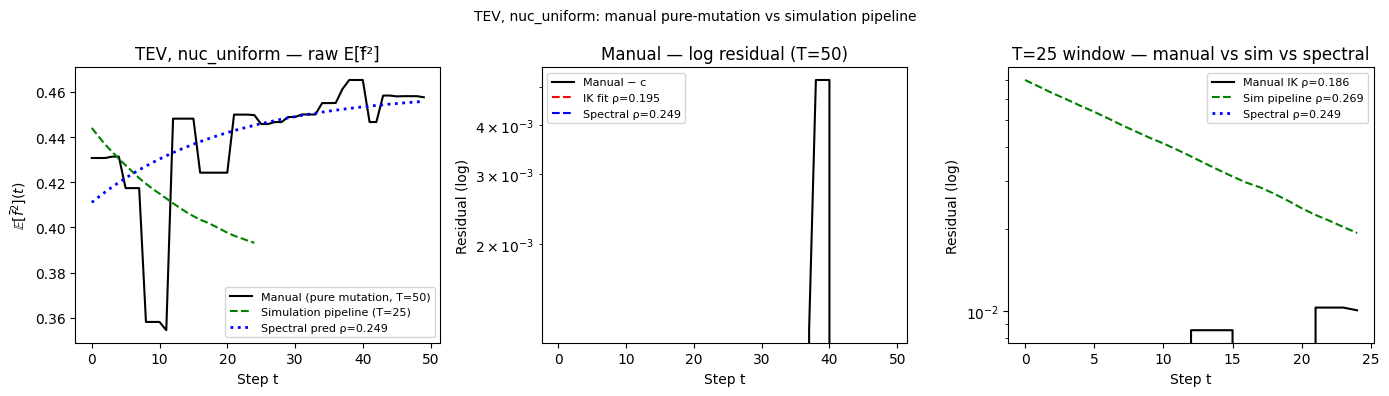


Summary for TEV, nuc_uniform:
  Spectral rho:                  0.2488
  Manual IK (T=50):              0.1949  (diff: -21.7%)
  Manual IK (T=25):              0.1865  (diff: -25.0%)
  Simulation pipeline (T=25):    0.2686  (diff: +8.0%)


In [11]:
# Load simulation pipeline curve for TEV to compare
with open(f'{SLIDE_DATA}/decay_curves_tev_nuc_uniform_m0.1_all_starts_v2.pkl', 'rb') as f:
    sim_raw = pickle.load(f)
h_sim   = sim_raw.mean(axis=2).reshape(-1, 25)
sim_curve = (h_sim**2).mean(axis=0)

rho_sim_raw, C_s, c_s = get_single_decay_rate_IK_v2(sim_curve, mut=0.1)
rho_sim = rho_sim_raw / 2
print(f'Simulation IK rho (T=25): {rho_sim:.4f}')

# Theoretical curve using spectral rho (same C,c as manual fit)
spec_curve_long = model_function_IK_v2(steps_long, rho_spec_tev * 2, C_m, c_m, mut=0.1)
spec_curve_25   = model_function_IK_v2(np.arange(25), rho_spec_tev * 2, C_25, c_25, mut=0.1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Raw curves
ax = axes[0]
ax.plot(steps_long, manual_curve, 'k-',  lw=1.5, label='Manual (pure mutation, T=50)')
ax.plot(np.arange(25), sim_curve, 'g--', lw=1.5, label='Simulation pipeline (T=25)')
ax.plot(steps_long, spec_curve_long, 'b:', lw=2, label=f'Spectral pred ρ={rho_spec_tev:.3f}')
ax.set_xlabel('Step t')
ax.set_ylabel('$\\mathbb{E}[\\bar{f}^2](t)$')
ax.set_title('TEV, nuc_uniform — raw E[f̄²]')
ax.legend(fontsize=8)

# Log residual (manual, T=50)
ax = axes[1]
ax.semilogy(steps_long, manual_curve - c_m + eps,    'k-',  lw=1.5, label='Manual − c')
ax.semilogy(steps_long, model_function_IK_v2(steps_long, rho_manual_raw, C_m, c_m, mut=0.1) - c_m + eps,
            'r--', lw=1.5, label=f'IK fit ρ={rho_manual:.3f}')
ax.semilogy(steps_long, spec_curve_long - c_m + eps, 'b--', lw=1.5, label=f'Spectral ρ={rho_spec_tev:.3f}')
ax.set_xlabel('Step t')
ax.set_ylabel('Residual (log)')
ax.set_title('Manual — log residual (T=50)')
ax.legend(fontsize=8)

# Log residual (first 25 steps, comparing manual vs simulation pipeline)
ax = axes[2]
s25 = np.arange(25)
ax.semilogy(s25, manual_curve[:25] - c_25 + eps, 'k-',  lw=1.5, label=f'Manual IK ρ={rho_25:.3f}')
ax.semilogy(s25, sim_curve - c_s + eps,          'g--', lw=1.5, label=f'Sim pipeline ρ={rho_sim:.3f}')
ax.semilogy(s25, spec_curve_25 - c_25 + eps,     'b:',  lw=2,   label=f'Spectral ρ={rho_spec_tev:.3f}')
ax.set_xlabel('Step t')
ax.set_ylabel('Residual (log)')
ax.set_title('T=25 window — manual vs sim vs spectral')
ax.legend(fontsize=8)

plt.suptitle('TEV, nuc_uniform: manual pure-mutation vs simulation pipeline', fontsize=10)
plt.tight_layout()
plt.savefig('figures/debug_tev_nuc_uniform_manual_vs_sim.pdf', bbox_inches='tight')
plt.show()

print(f'\nSummary for TEV, nuc_uniform:')
print(f'  Spectral rho:                  {rho_spec_tev:.4f}')
print(f'  Manual IK (T=50):              {rho_manual:.4f}  (diff: {100*(rho_manual-rho_spec_tev)/rho_spec_tev:+.1f}%)')
print(f'  Manual IK (T=25):              {rho_25:.4f}  (diff: {100*(rho_25-rho_spec_tev)/rho_spec_tev:+.1f}%)')
print(f'  Simulation pipeline (T=25):    {rho_sim:.4f}  (diff: {100*(rho_sim-rho_spec_tev)/rho_spec_tev:+.1f}%)')

## AA uniform comparison
Same analysis on AA uniform data — ground truth where IK and spectral should agree perfectly.

GB1: IK rho=0.5961  spectral=0.5976  diff=-0.0014 (-0.2%)
TrpB: IK rho=0.5888  spectral=0.6018  diff=-0.0130 (-2.2%)
TEV: IK rho=0.9347  spectral=0.9442  diff=-0.0095 (-1.0%)
ParD3: IK rho=0.3804  spectral=0.4226  diff=-0.0422 (-10.0%)


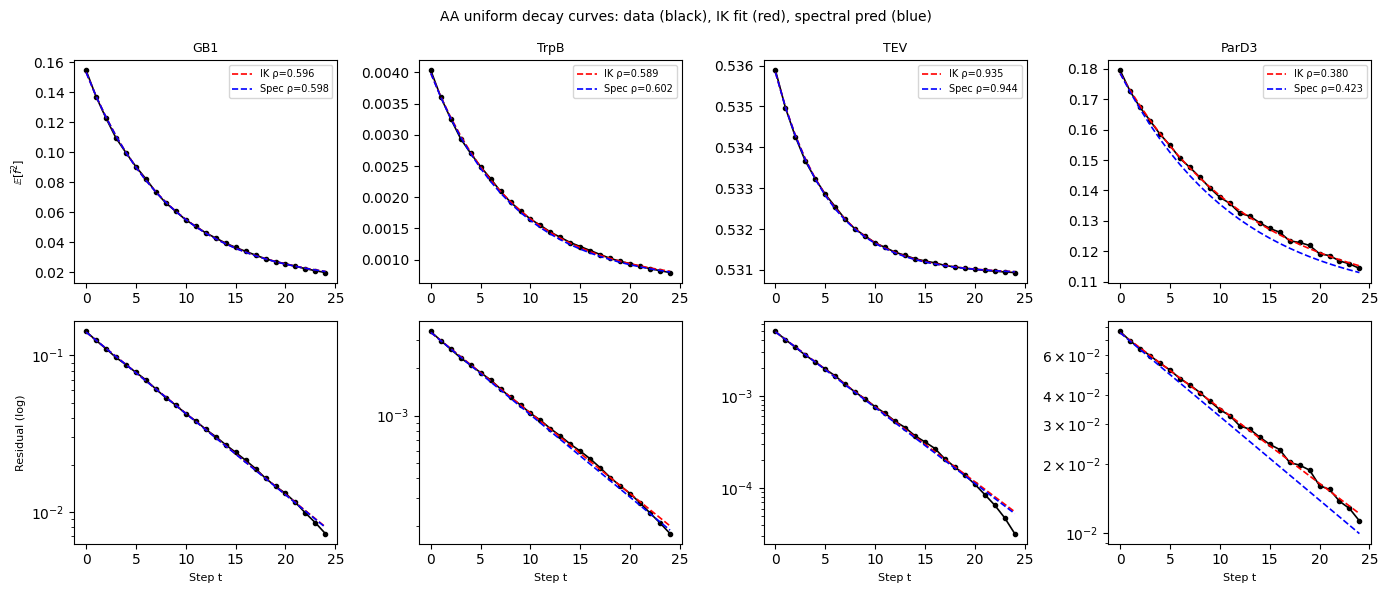

In [12]:
# Load AA uniform decay curves for all 4 landscapes
# Files: decay_curves_{ld}_m0.1_all_starts.pkl (same format, shape (-1,100,10,25))

LANDSCAPES_AA = {
    'gb1':   'GB1',
    'trpb':  'TrpB',
    'tev':   'TEV',
    'pard3': 'ParD3',
}

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
eps = 1e-10
steps = np.arange(25)

for col, (ld_key, ld_name) in enumerate(LANDSCAPES_AA.items()):
    with open(f'{SLIDE_DATA}/decay_curves_{ld_key}_m0.1_all_starts.pkl', 'rb') as f:
        raw_aa = pickle.load(f)
    raw_aa = np.array(raw_aa)
    h_aa = raw_aa.mean(axis=2).reshape(-1, 25)   # (N_starts, 25)
    curve_aa = (h_aa**2).mean(axis=0)             # (25,)

    rho_raw, C_aa, c_aa = get_single_decay_rate_IK_v2(curve_aa, mut=0.1)
    rho_ik_aa   = rho_raw / 2
    rho_spec_aa = spectral[ld_name]['aa_uniform']

    fit_ik_aa   = model_function_IK_v2(steps, rho_raw,         C_aa, c_aa, mut=0.1)
    fit_spec_aa = model_function_IK_v2(steps, rho_spec_aa * 2, C_aa, c_aa, mut=0.1)

    # Row 0: raw
    ax0 = axes[0, col]
    ax0.plot(steps, curve_aa,    'k.-', lw=1.2)
    ax0.plot(steps, fit_ik_aa,   'r--', lw=1.2, label=f'IK ρ={rho_ik_aa:.3f}')
    ax0.plot(steps, fit_spec_aa, 'b--', lw=1.2, label=f'Spec ρ={rho_spec_aa:.3f}')
    ax0.set_title(ld_name, fontsize=9)
    ax0.legend(fontsize=7)
    if col == 0: ax0.set_ylabel('$\\mathbb{E}[\\bar{f}^2]$', fontsize=8)

    # Row 1: log residual
    ax1 = axes[1, col]
    ax1.semilogy(steps, curve_aa - c_aa + eps,    'k.-', lw=1.2)
    ax1.semilogy(steps, fit_ik_aa - c_aa + eps,   'r--', lw=1.2)
    ax1.semilogy(steps, fit_spec_aa - c_aa + eps, 'b--', lw=1.2)
    ax1.set_xlabel('Step t', fontsize=8)
    if col == 0: ax1.set_ylabel('Residual (log)', fontsize=8)

    print(f'{ld_name}: IK rho={rho_ik_aa:.4f}  spectral={rho_spec_aa:.4f}  diff={rho_ik_aa-rho_spec_aa:+.4f} ({100*(rho_ik_aa-rho_spec_aa)/rho_spec_aa:+.1f}%)')

plt.suptitle('AA uniform decay curves: data (black), IK fit (red), spectral pred (blue)', fontsize=10)
plt.tight_layout()
plt.savefig('figures/debug_all_landscapes_aa_uniform_decay_curves.pdf', bbox_inches='tight')
plt.show()


In [13]:
# Side-by-side summary: AA uniform vs nuc uniform percent deviation from spectral
print(f'{'Landscape':<10} {'AA IK':>10} {'AA spec':>10} {'AA diff%':>10}  |  {'Nuc IK':>10} {'Nuc spec':>10} {'Nuc diff%':>10}')
print('-' * 75)

for ld_key, ld_name in LANDSCAPES_AA.items():
    # AA
    with open(f'{SLIDE_DATA}/decay_curves_{ld_key}_m0.1_all_starts.pkl', 'rb') as f:
        raw_aa = np.array(pickle.load(f))
    curve_aa = (raw_aa.mean(axis=2).reshape(-1,25)**2).mean(axis=0)
    rho_ik_aa  = get_single_decay_rate_IK_v2(curve_aa, mut=0.1)[0] / 2
    rho_spec_aa = spectral[ld_name]['aa_uniform']

    # Nuc
    with open(f'{SLIDE_DATA}/decay_curves_{ld_key}_nuc_uniform_m0.1_all_starts_v2.pkl', 'rb') as f:
        raw_nuc = np.array(pickle.load(f))
    curve_nuc = (raw_nuc.mean(axis=2).reshape(-1,25)**2).mean(axis=0)
    rho_ik_nuc  = get_single_decay_rate_IK_v2(curve_nuc, mut=0.1)[0] / 2
    rho_spec_nuc = spectral[ld_name]['nuc_uniform']

    print(f'{ld_name:<10} {rho_ik_aa:>10.4f} {rho_spec_aa:>10.4f} {100*(rho_ik_aa-rho_spec_aa)/rho_spec_aa:>+10.1f}%  |  '
          f'{rho_ik_nuc:>10.4f} {rho_spec_nuc:>10.4f} {100*(rho_ik_nuc-rho_spec_nuc)/rho_spec_nuc:>+10.1f}%')


Landscape       AA IK    AA spec   AA diff%  |      Nuc IK   Nuc spec  Nuc diff%
---------------------------------------------------------------------------
GB1            0.5961     0.5976       -0.2%  |      0.4362     0.4157       +4.9%
TrpB           0.5888     0.6018       -2.2%  |      0.3358     0.3040      +10.5%
TEV            0.9347     0.9442       -1.0%  |      0.2686     0.2488       +8.0%
ParD3          0.3804     0.4226      -10.0%  |      0.3528     0.3380       +4.4%


## Part 3: 75-step decay curves — most data-rich view

All genotypes averaged. Compares IK fit, spectral prediction, and true landscape constants.

In [14]:
from direvo_functions import CODON_MAPPER

_cm = np.array(CODON_MAPPER)  # (4,4,4) — AA index per codon, -1 = stop
print('stop codons:', (_cm == -1).sum(), '  sense codons:', (_cm >= 0).sum())


def true_constants(ld_array):
    """True asymptote constants for AA-uniform mutation."""
    f   = ld_array.flatten().astype(float)
    ef2 = np.mean(f**2)
    ef  = np.mean(f)
    c   = ef**2 / ef2
    return 1.0 - c, c


def true_constants_nuc(ld_array):
    """True asymptote constants for uniform-nuc mutation.

    Builds the full nuc-space fitness array (64^n_aa entries) using CODON_MAPPER,
    mapping stop codons to f_min exactly as the simulation does.
    Stationary distribution = uniform over all nuc sequences → all 64^n_aa codons
    equally weighted.

    c_true = E_nuc[f]^2 / E_AA[f^2]
      denominator: E_AA[f^2] because starting positions are uniform over AA genotypes
    """
    f     = ld_array.astype(float)
    f_min = f.min()
    n_aa  = ld_array.ndim

    # Extended landscape: index 20 = stop codon → f_min (same as simulation)
    f_ext = np.full((21,) * n_aa, f_min)
    f_ext[tuple([slice(20)] * n_aa)] = f

    # For each of 64 codons: AA index (0-19) or 20 for stop
    aa_idx = np.where(_cm.reshape(-1) >= 0, _cm.reshape(-1), 20)  # (64,)

    # Full nuc-space lookup: shape (64,) * n_aa  — all 64^n_aa codon combos
    f_nuc = f_ext[np.ix_(*([aa_idx] * n_aa))]   # uniform weight: 1/64^n_aa each

    ef_nuc = f_nuc.mean()    # E_nuc[f]  — all nuc seqs equally weighted
    ef2_aa = np.mean(f**2)   # E_AA[f^2] — denominator: uniform over AA starts

    c = ef_nuc**2 / ef2_aa
    return 1.0 - c, c


LANDSCAPES_75 = {
    'gb1':   ('GB1',   f'{LANDSCAPE_DIR}/GB1_landscape_array.pkl'),
    'trpb':  ('TrpB',  f'{LANDSCAPE_DIR}/TrpB_landscape_array.pkl'),
    'tev':   ('TEV',   f'{LANDSCAPE_DIR}/TEV_landscape_array.pkl'),
    'pard3': ('ParD3', f'{LANDSCAPE_DIR}/E3_landscape_array.pkl'),
}

ld_arrays = {}
for ld_key, (ld_name, ld_path) in LANDSCAPES_75.items():
    with open(ld_path, 'rb') as _f:
        ld_arrays[ld_key] = pickle.load(_f)
print('Landscapes loaded.')

# Quick sanity check: for AA uniform, true_constants_nuc should differ from true_constants
for ld_key, (ld_name, _) in LANDSCAPES_75.items():
    _, c_aa  = true_constants(ld_arrays[ld_key])
    _, c_nuc = true_constants_nuc(ld_arrays[ld_key])
    print(f'  {ld_name}: c_aa={c_aa:.4f}  c_nuc={c_nuc:.4f}  diff={c_nuc-c_aa:+.4f}')


stop codons: 3   sense codons: 61
Landscapes loaded.


/tmp/ipykernel_421727/972908360.py:58: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  ld_arrays[ld_key] = pickle.load(_f)


  GB1: c_aa=0.0408  c_nuc=0.0343  diff=-0.0065
  TrpB: c_aa=0.1101  c_nuc=0.0025  diff=-0.1077
  TEV: c_aa=0.9905  c_nuc=0.6816  diff=-0.3090
  ParD3: c_aa=0.5804  c_nuc=0.3003  diff=-0.2801


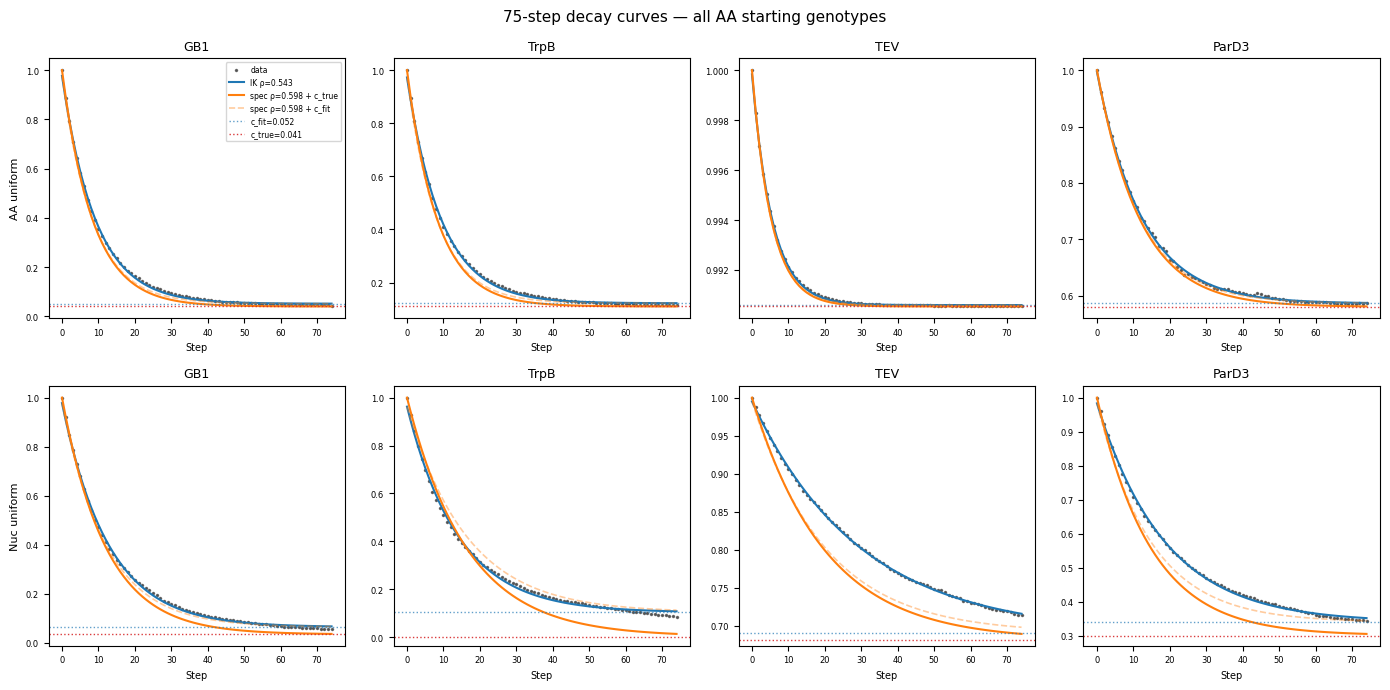

In [15]:
MODELS_75 = [
    ('aa_uniform',  'AA uniform',  'aa_uniform_m0.1_all_starts_75steps'),
    ('nuc_uniform', 'Nuc uniform', 'nuc_uniform_m0.1_all_starts_75steps'),
]

eps      = 1e-10
steps_75 = np.arange(75)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('75-step decay curves — all AA starting genotypes', fontsize=11)

for row, (model_key, model_name, model_suffix) in enumerate(MODELS_75):
    # Choose correct true_constants function
    tc_fn = true_constants if model_key == 'aa_uniform' else true_constants_nuc

    for col, (ld_key, (ld_name, _)) in enumerate(LANDSCAPES_75.items()):
        ax = axes[row, col]

        fpath = f'{SLIDE_DATA}/decay_curves_{ld_key}_{model_suffix}.pkl'
        with open(fpath, 'rb') as f:
            raw = pickle.load(f)

        # Mean over seeds, then E[f̄²](t) averaged over all starting points
        h          = raw.mean(axis=2).reshape(-1, 75)   # (N_starts, 75)
        curve      = (h**2).mean(axis=0)                # (75,)
        curve_norm = curve / (curve[0] + eps)

        # IK fit
        rho_raw, C_fit, c_fit = get_single_decay_rate_IK_v2(curve_norm, mut=0.1, num_steps=75)
        rho_ik = rho_raw / 2

        # Spectral rho
        spec_key = 'aa_uniform' if model_key == 'aa_uniform' else 'nuc_uniform'
        rho_spec  = spectral[ld_name].get(spec_key, float('nan'))

        # True landscape constants (model-appropriate)
        C_true, c_true = tc_fn(ld_arrays[ld_key])

        # Curves
        fit_ik         = model_function_IK_v2(steps_75, rho_raw,       C_fit,  c_fit,  mut=0.1)
        # Spectral pred with *fitted* asymptote (faint: tells us about rate only)
        fit_spec_cfit  = model_function_IK_v2(steps_75, rho_spec * 2,  C_fit,  c_fit,  mut=0.1)
        # Spectral pred with *true* asymptote (solid reference)
        fit_spec_ctrue = model_function_IK_v2(steps_75, rho_spec * 2,  C_true, c_true, mut=0.1)

        ax.plot(steps_75, curve_norm,     'k.',  ms=3,  alpha=0.5,  label='data')
        ax.plot(steps_75, fit_ik,         'C0-', lw=1.5,            label=f'IK ρ={rho_ik:.3f}')
        ax.plot(steps_75, fit_spec_ctrue, 'C1-', lw=1.5,            label=f'spec ρ={rho_spec:.3f} + c_true')
        ax.plot(steps_75, fit_spec_cfit,  'C1--',lw=1.2, alpha=0.4, label=f'spec ρ={rho_spec:.3f} + c_fit')
        ax.axhline(c_fit,  color='C0', ls=':', lw=1.0, alpha=0.7,   label=f'c_fit={c_fit:.3f}')
        ax.axhline(c_true, color='C3', ls=':', lw=1.0, alpha=0.9,   label=f'c_true={c_true:.3f}')

        ax.set_title(ld_name, fontsize=9)
        ax.set_xlabel('Step', fontsize=7)
        if col == 0:
            ax.set_ylabel(model_name, fontsize=8)
        ax.tick_params(labelsize=6)
        if row == 0 and col == 0:
            ax.legend(fontsize=5.5, loc='upper right')

plt.tight_layout()
plt.savefig('figures/debug_75steps_decay_curves.pdf', dpi=200, bbox_inches='tight')
plt.show()


In [16]:
from IPython.display import display
import pandas as pd

rows = []
eps  = 1e-10

for model_key, model_name, model_suffix in MODELS_75:
    spec_key = 'aa_uniform' if model_key == 'aa_uniform' else 'nuc_uniform'
    tc_fn    = true_constants if model_key == 'aa_uniform' else true_constants_nuc

    for ld_key, (ld_name, _) in LANDSCAPES_75.items():
        fpath = f'{SLIDE_DATA}/decay_curves_{ld_key}_{model_suffix}.pkl'
        with open(fpath, 'rb') as f:
            raw = pickle.load(f)
        h          = raw.mean(axis=2).reshape(-1, 75)
        curve      = (h**2).mean(axis=0)
        curve_norm = curve / (curve[0] + eps)

        rho_raw, C_fit, c_fit = get_single_decay_rate_IK_v2(curve_norm, mut=0.1, num_steps=75)
        rho_ik   = rho_raw / 2
        rho_spec = spectral[ld_name].get(spec_key, float('nan'))
        C_true, c_true = tc_fn(ld_arrays[ld_key])

        rows.append({
            'Model':     model_name,
            'Landscape': ld_name,
            'rho_IK':    f'{rho_ik:.4f}',
            'rho_spec':  f'{rho_spec:.4f}',
            'Delta_rho%':f'{(rho_ik - rho_spec)/rho_spec*100:+.1f}%',
            'C_fit':     f'{C_fit:.4f}',
            'C_true':    f'{C_true:.4f}',
            'c_fit':     f'{c_fit:.4f}',
            'c_true':    f'{c_true:.4f}',
        })

df = pd.DataFrame(rows)
display(df.to_string(index=False))


'      Model Landscape rho_IK rho_spec Delta_rho%  C_fit C_true  c_fit c_true\n AA uniform       GB1 0.5429   0.5976      -9.2% 0.9247 0.9592 0.0519 0.0408\n AA uniform      TrpB 0.5266   0.6018     -12.5% 0.8504 0.8899 0.1221 0.1101\n AA uniform       TEV 0.8959   0.9442      -5.1% 0.0092 0.0095 0.9906 0.9905\n AA uniform     ParD3 0.4037   0.4226      -4.5% 0.4105 0.4196 0.5863 0.5804\nNuc uniform       GB1 0.3915   0.4157      -5.8% 0.9133 0.9657 0.0643 0.0343\nNuc uniform      TrpB 0.3526   0.3040     +16.0% 0.8592 0.9975 0.1032 0.0025\nNuc uniform       TEV 0.1678   0.2488     -32.5% 0.3044 0.3184 0.6907 0.6816\nNuc uniform     ParD3 0.2685   0.3380     -20.6% 0.6439 0.6997 0.3393 0.3003'